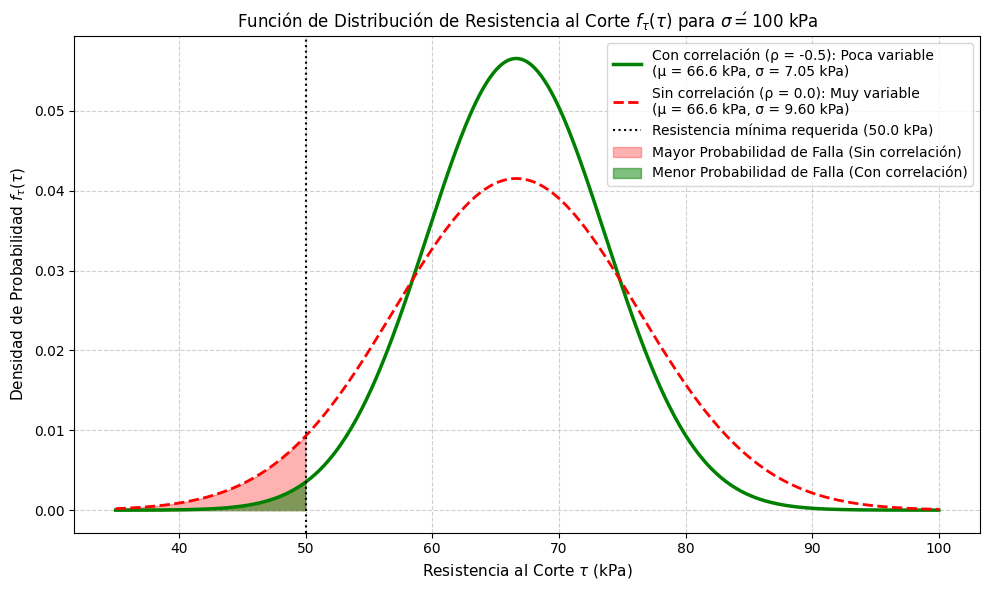

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, lognorm

# 1. Parámetros de entrada
mu_c, sigma_c = 20.0, 8.0          # Cohesión (kPa) - CV = 40%
mu_phi, sigma_phi = 25.0, 2.5       # Ángulo de fricción (grados) - CV = 10%
sigma_p = 100.0                     # Esfuerzo normal efectivo (kPa)
rho = -0.5                          # Coeficiente de correlación c - phi

# Conversión de phi a radianes
sigma_phi_rad = np.radians(sigma_phi)

# Propagación por Taylor (FOSM)
mu_tan = np.tan(np.radians(mu_phi))
sigma_tan = (1 / np.cos(np.radians(mu_phi)))**2 * sigma_phi_rad

# Calculo de medias y desviaciones estándar para tau
mu_tau = mu_c + sigma_p * mu_tan

# Con correlación (rho = -0.5)
var_tau_corr = sigma_c**2 + (sigma_p**2)*(sigma_tan**2) + 2*sigma_p*rho*sigma_c*sigma_tan
sigma_tau_corr = np.sqrt(var_tau_corr)

# Sin correlación (rho = 0.0)
var_tau_nocorr = sigma_c**2 + (sigma_p**2)*(sigma_tan**2)
sigma_tau_nocorr = np.sqrt(var_tau_nocorr)

# 2. Generación de curvas de densidad de probabilidad
tau_axis = np.linspace(35, 100, 500)
pdf_corr = norm.pdf(tau_axis, loc=mu_tau, scale=sigma_tau_corr)
pdf_nocorr = norm.pdf(tau_axis, loc=mu_tau, scale=sigma_tau_nocorr)

# 3. Graficación
plt.figure(figsize=(10, 6))

plt.plot(tau_axis, pdf_corr, 'g-', lw=2.5, 
         label=f'Con correlación (ρ = -0.5): Poca variable\n(μ = {mu_tau:.1f} kPa, σ = {sigma_tau_corr:.2f} kPa)')

plt.plot(tau_axis, pdf_nocorr, 'r--', lw=2.0, 
         label=f'Sin correlación (ρ = 0.0): Muy variable\n(μ = {mu_tau:.1f} kPa, σ = {sigma_tau_nocorr:.2f} kPa)')

# Resaltar la diferencia en las colas (área de falla hipotética si tau_requerido = 50 kPa)
tau_critico = 50.0
plt.axvline(tau_critico, color='k', linestyle=':', label=f'Resistencia mínima requerida ({tau_critico} kPa)')
plt.fill_between(tau_axis[tau_axis <= tau_critico], pdf_nocorr[tau_axis <= tau_critico], 
                 color='red', alpha=0.3, label='Mayor Probabilidad de Falla (Sin correlación)')
plt.fill_between(tau_axis[tau_axis <= tau_critico], pdf_corr[tau_axis <= tau_critico], 
                 color='green', alpha=0.5, label='Menor Probabilidad de Falla (Con correlación)')

plt.title(r'Función de Distribución de Resistencia al Corte $f_\tau(\tau)$ para $\sigma\' = 100\text{ kPa}$', fontsize=12)
plt.xlabel(r'Resistencia al Corte $\tau$ (kPa)', fontsize=11)
plt.ylabel(r'Densidad de Probabilidad $f_\tau(\tau)$', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

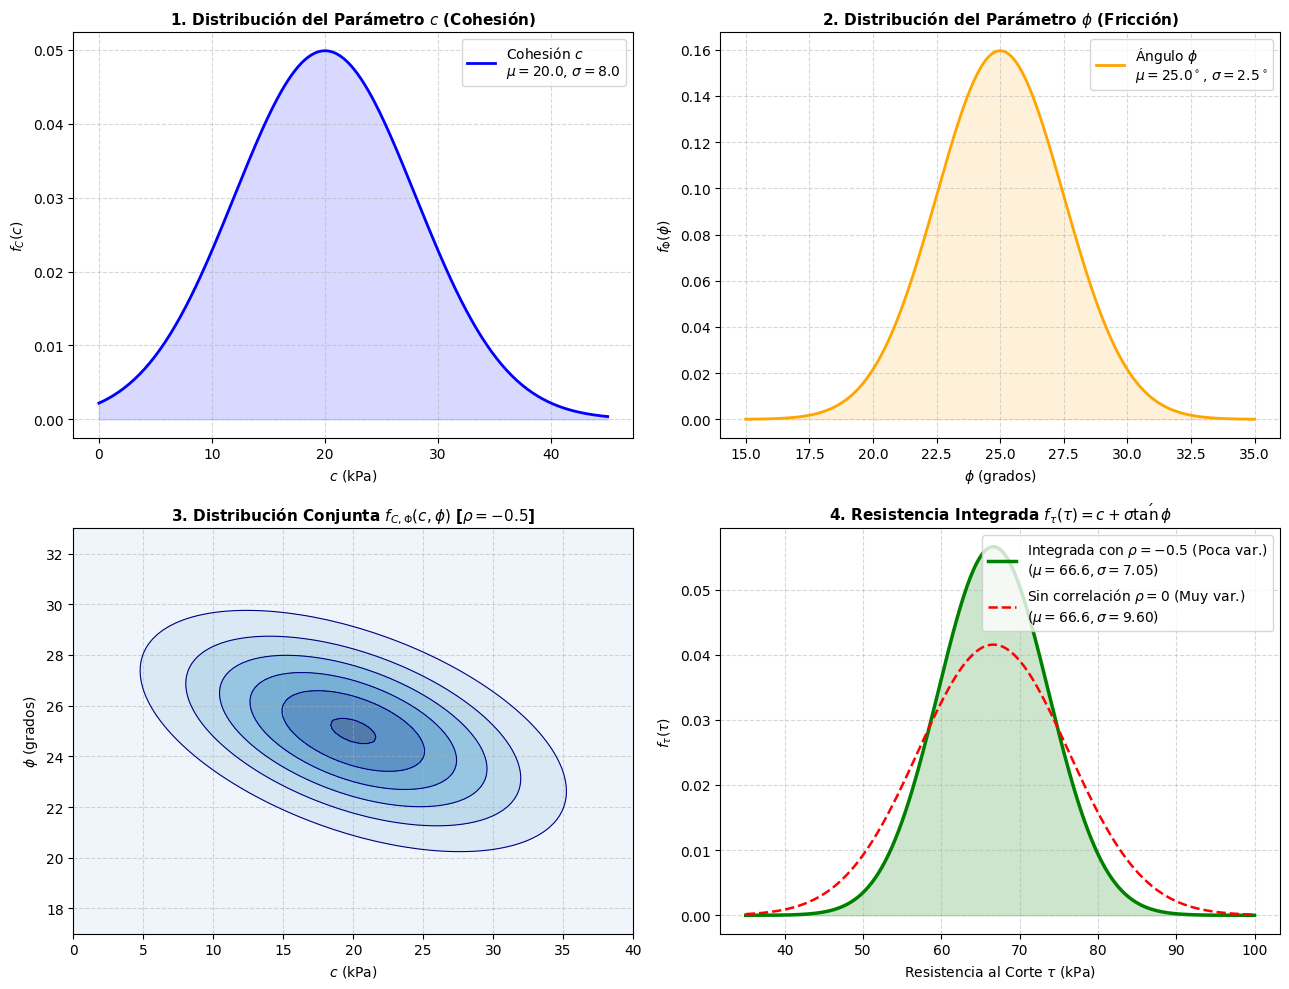

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal

# ---------------------------------------------------------
# 1. Parámetros de Entrada y Correlación
# ---------------------------------------------------------
mu_c, sigma_c = 20.0, 8.0           # Cohesión (kPa) - CV = 40%
mu_phi, sigma_phi = 25.0, 2.5        # Ángulo de fricción (grados) - CV = 10%
sigma_p = 100.0                      # Esfuerzo normal efectivo (kPa)
rho = -0.5                           # Correlación negativa c - phi

# Conversión a radianes y propagación a tan(phi)
sigma_phi_rad = np.radians(sigma_phi)
mu_tan = np.tan(np.radians(mu_phi))
sigma_tan = (1 / np.cos(np.radians(mu_phi)))**2 * sigma_phi_rad

# Resistencia al corte resultante (Propagación por FOSM)
mu_tau = mu_c + sigma_p * mu_tan
var_tau_corr = sigma_c**2 + (sigma_p**2)*(sigma_tan**2) + 2*sigma_p*rho*sigma_c*sigma_tan
sigma_tau_corr = np.sqrt(var_tau_corr)

var_tau_nocorr = sigma_c**2 + (sigma_p**2)*(sigma_tan**2)
sigma_tau_nocorr = np.sqrt(var_tau_nocorr)

# ---------------------------------------------------------
# 2. Configuración de la Figura (2x2 Grid)
# ---------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(13, 10))

# --- PANEL A: Distribución Marginal de la Cohesión c ---
c_axis = np.linspace(0, 45, 300)
pdf_c = norm.pdf(c_axis, loc=mu_c, scale=sigma_c)
axs[0, 0].plot(c_axis, pdf_c, 'b-', lw=2, label=f'Cohesión $c$\n$\mu={mu_c}$, $\sigma={sigma_c}$')
axs[0, 0].fill_between(c_axis, pdf_c, color='blue', alpha=0.15)
axs[0, 0].set_title('1. Distribución del Parámetro $c$ (Cohesión)', fontsize=11, fontweight='bold')
axs[0, 0].set_xlabel('$c$ (kPa)')
axs[0, 0].set_ylabel('$f_C(c)$')
axs[0, 0].grid(True, linestyle='--', alpha=0.5)
axs[0, 0].legend(loc='upper right')

# --- PANEL B: Distribución Marginal del Ángulo de Fricción phi ---
phi_axis = np.linspace(15, 35, 300)
pdf_phi = norm.pdf(phi_axis, loc=mu_phi, scale=sigma_phi)
axs[0, 1].plot(phi_axis, pdf_phi, 'orange', lw=2, label=f'Ángulo $\phi$\n$\mu={mu_phi}^\circ$, $\sigma={sigma_phi}^\circ$')
axs[0, 1].fill_between(phi_axis, pdf_phi, color='orange', alpha=0.15)
axs[0, 1].set_title(r'2. Distribución del Parámetro $\phi$ (Fricción)', fontsize=11, fontweight='bold')
axs[0, 1].set_xlabel(r'$\phi$ (grados)')
axs[0, 1].set_ylabel(r'$f_\Phi(\phi)$')
axs[0, 1].grid(True, linestyle='--', alpha=0.5)
axs[0, 1].legend(loc='upper right')

# --- PANEL C: Distribución Conjunta f(c, phi) e Interacción ---
C, PHI = np.meshgrid(np.linspace(0, 40, 100), np.linspace(17, 33, 100))
pos = np.dstack((C, PHI))
cov_matrix = [[sigma_c**2, rho * sigma_c * sigma_phi], 
              [rho * sigma_c * sigma_phi, sigma_phi**2]]
rv = multivariate_normal([mu_c, mu_phi], cov_matrix)
axs[1, 0].contourf(C, PHI, rv.pdf(pos), cmap='Blues', alpha=0.7)
axs[1, 0].contour(C, PHI, rv.pdf(pos), colors='navy', linewidths=0.8)
axs[1, 0].set_title(r'3. Distribución Conjunta $f_{C,\Phi}(c, \phi)$ [$\rho = -0.5$]', fontsize=11, fontweight='bold')
axs[1, 0].set_xlabel('$c$ (kPa)')
axs[1, 0].set_ylabel(r'$\phi$ (grados)')
axs[1, 0].grid(True, linestyle='--', alpha=0.5)

# --- PANEL D: Función de Resistencia al Corte Integrada f(tau) ---
tau_axis = np.linspace(35, 100, 300)
pdf_tau_corr = norm.pdf(tau_axis, loc=mu_tau, scale=sigma_tau_corr)
pdf_tau_nocorr = norm.pdf(tau_axis, loc=mu_tau, scale=sigma_tau_nocorr)

axs[1, 1].plot(tau_axis, pdf_tau_corr, 'g-', lw=2.5, 
               label=f'Integrada con $\\rho=-0.5$ (Poca var.)\n$(\mu={mu_tau:.1f}, \sigma={sigma_tau_corr:.2f})$')
axs[1, 1].plot(tau_axis, pdf_tau_nocorr, 'r--', lw=1.8, 
               label=f'Sin correlación $\\rho=0$ (Muy var.)\n$(\mu={mu_tau:.1f}, \sigma={sigma_tau_nocorr:.2f})$')

axs[1, 1].fill_between(tau_axis, pdf_tau_corr, color='green', alpha=0.2)
axs[1, 1].set_title(r'4. Resistencia Integrada $f_\tau(\tau) = c + \sigma\'\tan\phi$', fontsize=11, fontweight='bold')
axs[1, 1].set_xlabel(r'Resistencia al Corte $\tau$ (kPa)')
axs[1, 1].set_ylabel(r'$f_\tau(\tau)$')
axs[1, 1].grid(True, linestyle='--', alpha=0.5)
axs[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()